# Training Log Visualizer

Load a YOLO-style `results.csv` file and visualize how training progressed over epochs.

## Usage

1. Set `CSV_PATH` to your training log file.
2. Run all cells.
3. Inspect the generated plots for losses, validation metrics, and learning-rate behavior.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [8]:
# Update this path for your run
CSV_PATH = "/home/khanh/Projects/DifficultyAgri/results/04_train_and_scoring_mulseed_gwhd/seed_456/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/train/results.csv"
SMOOTH_WINDOW = 3

In [9]:
def load_training_log(csv_path: str) -> pd.DataFrame:
    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(f"CSV file not found: {path}")

    df = pd.read_csv(path)
    if "epoch" not in df.columns:
        raise ValueError("Expected an 'epoch' column in the CSV file.")

    return df


def pick_columns(df: pd.DataFrame):
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    loss_cols = [c for c in numeric_cols if "loss" in c.lower()]
    metric_cols = [c for c in numeric_cols if c.startswith("metrics/")]
    lr_cols = [c for c in numeric_cols if c.startswith("lr/")]

    train_loss_cols = [c for c in loss_cols if c.startswith("train/")]
    val_loss_cols = [c for c in loss_cols if c.startswith("val/")]

    return train_loss_cols, val_loss_cols, metric_cols, lr_cols


def _plot_group(ax, df: pd.DataFrame, x_col: str, cols, title: str, smooth_window: int = 1):
    if not cols:
        ax.set_title(f"{title} (no columns found)")
        ax.axis("off")
        return

    for col in cols:
        y = df[col]
        ax.plot(df[x_col], y, alpha=0.35, linewidth=1.2, label=f"{col} raw")
        if smooth_window > 1:
            y_smooth = y.rolling(window=smooth_window, min_periods=1).mean()
            ax.plot(df[x_col], y_smooth, linewidth=2.0, label=f"{col} smooth")

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.legend(fontsize=8, ncol=1)


def plot_training_process(df: pd.DataFrame, smooth_window: int = 1):
    x_col = "epoch"
    train_loss_cols, val_loss_cols, metric_cols, lr_cols = pick_columns(df)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    _plot_group(axes[0, 0], df, x_col, train_loss_cols, "Train Losses", smooth_window)
    _plot_group(axes[0, 1], df, x_col, val_loss_cols, "Validation Losses", smooth_window)
    _plot_group(axes[1, 0], df, x_col, metric_cols, "Validation Metrics", smooth_window)
    _plot_group(axes[1, 1], df, x_col, lr_cols, "Learning Rate", smooth_window)

    fig.suptitle("Training Process Overview", fontsize=16, y=1.02)
    fig.tight_layout()
    plt.show()

In [10]:
df_log = load_training_log(CSV_PATH)
print(f"Loaded: {CSV_PATH}")
print(f"Shape: {df_log.shape}")
display(df_log.head())

Loaded: /home/khanh/Projects/DifficultyAgri/results/04_train_and_scoring_mulseed_gwhd/seed_456/Step_2_Train_and_Evaluate_BASELINE_MODEL/train_results/train/results.csv
Shape: (15, 15)


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,20.7728,1.62505,1.04387,1.41920,0.88673,0.83539,0.90483,0.48771,1.62625,0.80295,1.36532,0.000663,0.000663,0.000663
1,2,38.7590,1.50818,0.75727,1.30847,0.88494,0.84528,0.91382,0.49752,1.60725,0.80371,1.34964,0.001316,0.001316,0.001316
2,3,56.5557,1.47973,0.72898,1.29437,0.89674,0.85225,0.91476,0.50008,1.58309,0.80841,1.33102,0.001957,0.001957,0.001957
3,4,74.1493,1.45181,0.70323,1.27562,0.90926,0.85460,0.92616,0.50965,1.61025,0.74836,1.34152,0.001941,0.001941,0.001941
4,5,93.1415,1.42265,0.67437,1.26078,0.89732,0.85523,0.92250,0.50697,1.57907,0.76177,1.33970,0.001921,0.001921,0.001921


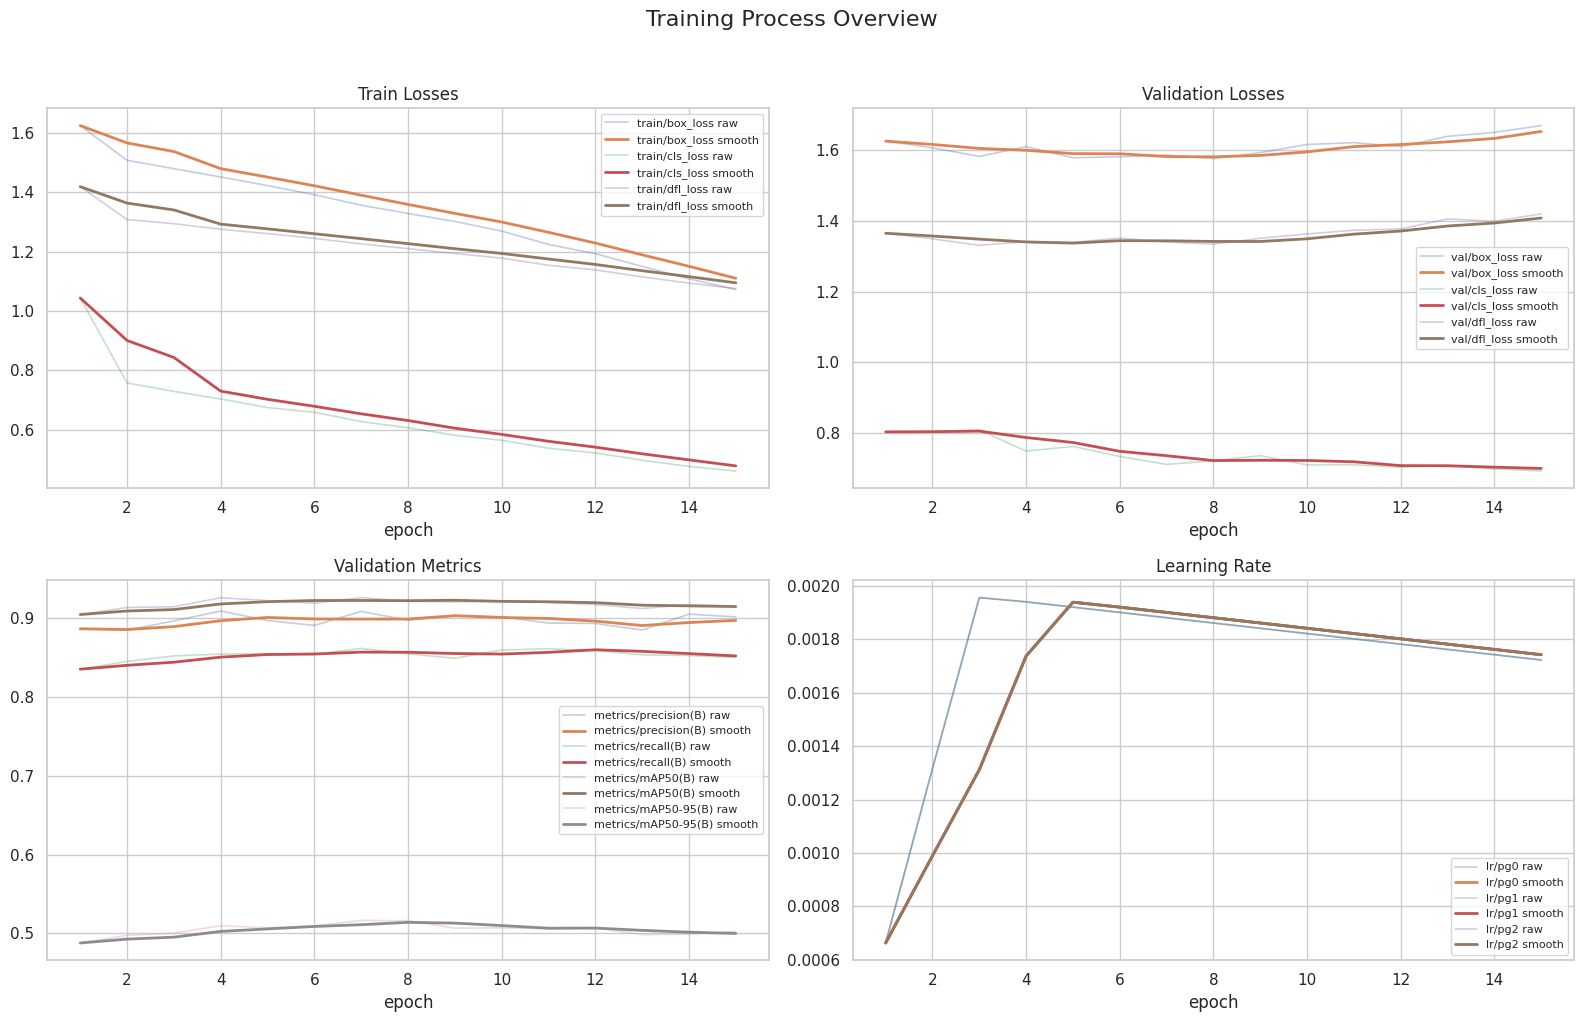

In [11]:
plot_training_process(df_log, smooth_window=SMOOTH_WINDOW)

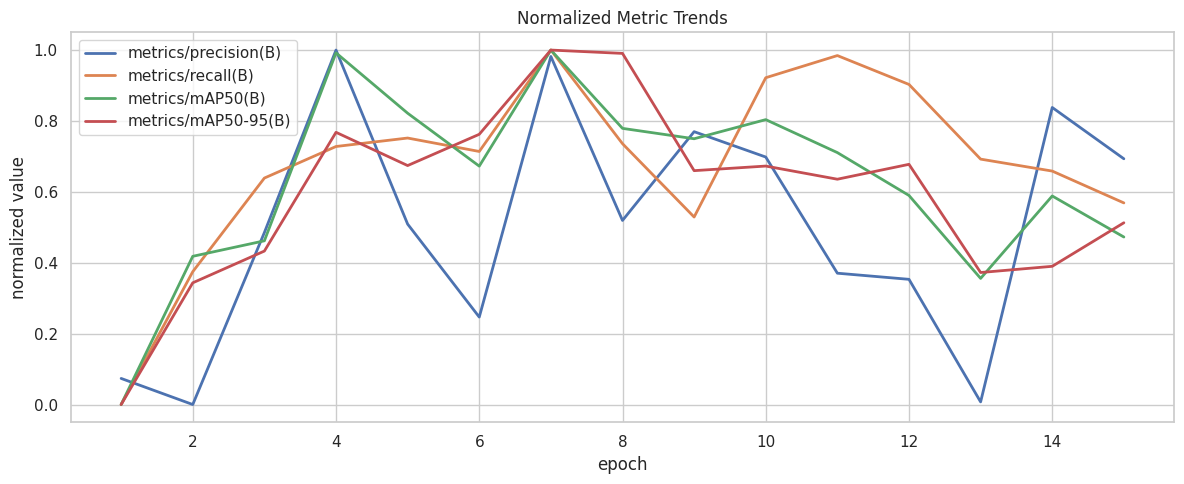

In [12]:
# Optional: normalize selected metrics into one chart to compare trends
candidate_cols = [
    c
    for c in ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
    if c in df_log.columns
]

if candidate_cols:
    scaled = (df_log[candidate_cols] - df_log[candidate_cols].min()) / (df_log[candidate_cols].max() - df_log[candidate_cols].min() + 1e-12)
    plt.figure(figsize=(12, 5))
    for col in candidate_cols:
        plt.plot(df_log["epoch"], scaled[col], label=col, linewidth=2)
    plt.title("Normalized Metric Trends")
    plt.xlabel("epoch")
    plt.ylabel("normalized value")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No expected metric columns found for normalized trend plot.")